# ⚡ Regional Energy Market Price Prediction & Manufacturing Strategy Optimizer

This notebook builds a full-stack energy price forecasting and strategic planning system for a major manufacturer. It covers:

- **Tactical forecasting**: 30/60/90-day energy price predictions
- **Strategic planning**: Annual peak-price risk calendar, shutdown scheduling, and energy reserve buildups
- **Demand Response**: Modeling utility incentive programs that pay the manufacturer to be offline during grid stress events
- **Data drivers**: Regional demographics, commodity prices, weather (HDD/CDD), job openings, and consumer foot traffic

---
> **How to use this notebook**: Run all cells top-to-bottom. Synthetic data is generated by default so no API keys are required to get started. Replace synthetic loaders with real data sources (EIA API, NOAA, BLS, Placer.ai, etc.) as needed.

**Sections:**
1. Import Required Libraries
2. Load and Explore Raw Data Sources
3. Data Preprocessing and Feature Engineering
4. Exploratory Data Analysis (EDA) and Correlation Analysis
5. Time Series Decomposition of Energy Prices
6. Build Baseline Forecasting Model (Prophet / SARIMA)
7. Build Advanced ML Forecasting Model (XGBoost + SHAP)
8. Peak Price Period Detection
9. Demand Response & Utility Incentive Modeling
10. Shutdown and Reserve Strategy Optimizer
11. Tactical vs Strategic Planning Dashboard

## Section 1 — Import Required Libraries

Install and import all dependencies. The cell below installs missing packages automatically.

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q", "--user"])

required = [
    "pandas", "numpy", "scikit-learn", "xgboost>=1.6,<3.0", "lightgbm",
    "statsmodels", "matplotlib", "seaborn", "plotly", "scipy",
    "shap", "prophet", "pulp", "holidays", "requests"
]
for pkg in required:
    bare = pkg.split(">=")[0].split("==")[0].split("<")[0].replace("-", "_")
    try:
        __import__(bare)
        # For versioned requirements, let pip verify and install/upgrade if needed
        if any(op in pkg for op in [">=", "==", "<"]):
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", pkg, "-q", "--user"],
                stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
            )
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)

print("✅ All packages ready.")


Installing scikit-learn...
✅ All packages ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# Stats & ML
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
import shap
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from scipy import stats, optimize
import holidays

# Plotting defaults
plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
sns.set_palette("husl")

REGION   = "Midwest ISO (MISO)"  # ← Change to your region
YEAR     = 2025
FACILITY_MW = 85          # Manufacturer peak load in MW
SHUTDOWN_COST_PER_HOUR = 12_500   # $ operational cost per shutdown hour
INCENTIVE_RATE = 45       # $ / MWh paid by utility for demand reduction
RESERVE_CAPACITY_MWH = 500  # On-site battery/reserve capacity in MWh

print(f"✅ Config set for {REGION}  |  Facility: {FACILITY_MW} MW  |  "
      f"Reserve: {RESERVE_CAPACITY_MWH} MWh  |  Incentive: ${INCENTIVE_RATE}/MWh")

✅ Config set for Midwest ISO (MISO)  |  Facility: 85 MW  |  Reserve: 500 MWh  |  Incentive: $45/MWh


## Section 2 — Load and Explore Raw Data Sources

Data is synthesized here to replicate realistic patterns. Replace each loader with live API calls:

| Data Source | Live API / Provider |
|---|---|
| Regional electricity prices (LMP) | [EIA Open Data API](https://www.eia.gov/opendata/) · MISO / PJM APIs |
| Weather (temp, humidity, extreme events) | NOAA Climate Data Online (CDO) API |
| Natural gas spot prices | EIA Henry Hub · CME futures |
| Coal & oil prices | EIA · World Bank Commodity API |
| Job openings (JOLTS) | BLS Public Data API |
| Consumer foot traffic | Placer.ai · SafeGraph · Google Mobility |
| Regional demographics / population | US Census Bureau API |

In [21]:
np.random.seed(42)

# ── Date index: 5 years of daily data ──────────────────────────────────────
dates = pd.date_range("2020-01-01", "2025-12-31", freq="D")
n = len(dates)

# ── 1. Energy prices ($/MWh) — seasonal peaks in summer & winter ──────────
seasonal = (
    18 * np.sin(2 * np.pi * np.arange(n) / 365 + np.pi)   # winter peak
    + 10 * np.sin(4 * np.pi * np.arange(n) / 365)          # secondary summer peak
)
trend = np.linspace(0, 8, n)                                # long-term upward drift
price_noise = np.random.normal(0, 6, n)
spikes = np.random.choice([0]*n, n, replace=False)         # rare spikes
spike_mask = np.random.random(n) < 0.015
spike_vals = np.where(spike_mask, np.random.uniform(60, 120, n), 0)
energy_prices = 45 + seasonal + trend + price_noise + spike_vals
energy_prices = np.clip(energy_prices, 5, 250)

df_energy = pd.DataFrame({"date": dates, "lmp_price": energy_prices})

# ── 2. Weather data ────────────────────────────────────────────────────────
temp_base = 55 + 30 * np.sin(2 * np.pi * np.arange(n) / 365 - np.pi / 2)
temperature = temp_base + np.random.normal(0, 5, n)
humidity = 55 + 20 * np.sin(2 * np.pi * np.arange(n) / 365) + np.random.normal(0, 8, n)
hdd = np.maximum(0, 65 - temperature)
cdd = np.maximum(0, temperature - 65)
df_weather = pd.DataFrame({"date": dates, "temp_f": temperature,
                            "humidity_pct": humidity, "hdd": hdd, "cdd": cdd})

# ── 3. Commodity prices ────────────────────────────────────────────────────
gas_base = 3.5 + np.cumsum(np.random.normal(0, 0.04, n))
gas_price = np.clip(gas_base, 1.5, 12.0)
coal_price = 60 + np.cumsum(np.random.normal(0, 0.3, n))
coal_price = np.clip(coal_price, 40, 180)
oil_price  = 70 + np.cumsum(np.random.normal(0, 0.5, n))
oil_price  = np.clip(oil_price, 30, 130)
df_commodities = pd.DataFrame({"date": dates, "natgas_usd_mmbtu": gas_price,
                                "coal_usd_ton": coal_price, "oil_usd_bbl": oil_price})

# ── 4. Demographics / population ──────────────────────────────────────────
population = 2_400_000 + np.linspace(0, 120_000, n) + np.random.normal(0, 2000, n)
df_demographics = pd.DataFrame({"date": dates, "regional_population": population})

# ── 5. Job openings (JOLTS proxy) ─────────────────────────────────────────
job_seasonal = 5000 * np.sin(2 * np.pi * np.arange(n) / 365 + 1.0)
job_openings = 85_000 + job_seasonal + np.cumsum(np.random.normal(0, 200, n))
df_jobs = pd.DataFrame({"date": dates, "job_openings": np.clip(job_openings, 40000, 140000)})

# ── 6. Consumer foot traffic (indexed, 100 = baseline) ────────────────────
traffic_seasonal = 12 * np.sin(2 * np.pi * np.arange(n) / 365 - 0.5)
foot_traffic = 100 + traffic_seasonal + np.random.normal(0, 4, n)
foot_traffic[:365] *= 0.72   # COVID impact 2020
df_traffic = pd.DataFrame({"date": dates, "foot_traffic_idx": np.clip(foot_traffic, 30, 145)})

print("Data shapes:")
for name, df in [("Energy", df_energy), ("Weather", df_weather),
                 ("Commodities", df_commodities), ("Demographics", df_demographics),
                 ("Jobs", df_jobs), ("Traffic", df_traffic)]:
    print(f"  {name:14s}: {df.shape}  |  date range: {df['date'].min().date()} → {df['date'].max().date()}")

Data shapes:
  Energy        : (2192, 2)  |  date range: 2020-01-01 → 2025-12-31
  Weather       : (2192, 5)  |  date range: 2020-01-01 → 2025-12-31
  Commodities   : (2192, 4)  |  date range: 2020-01-01 → 2025-12-31
  Demographics  : (2192, 2)  |  date range: 2020-01-01 → 2025-12-31
  Jobs          : (2192, 2)  |  date range: 2020-01-01 → 2025-12-31
  Traffic       : (2192, 2)  |  date range: 2020-01-01 → 2025-12-31


In [22]:
# Quick overview of each dataset
datasets = {"Energy Prices": df_energy, "Weather": df_weather,
            "Commodities": df_commodities, "Demographics": df_demographics,
            "Job Openings": df_jobs, "Foot Traffic": df_traffic}

for title, df in datasets.items():
    print(f"\n{'='*55}")
    print(f"  {title}")
    print(f"{'='*55}")
    display(df.head(3))
    print(df.describe().round(2))


  Energy Prices


,date,lmp_price
0,2020-01-01,47.980285
1,2020-01-02,44.208441
2,2020-01-03,48.961869


                      date  lmp_price
count                 2192    2192.00
mean   2022-12-31 12:00:00      50.37
min    2020-01-01 00:00:00       9.54
25%    2021-07-01 18:00:00      37.86
50%    2022-12-31 12:00:00      49.37
75%    2024-07-01 06:00:00      61.74
max    2025-12-31 00:00:00     168.79
std                    NaN      19.08

  Weather


,date,temp_f,humidity_pct,hdd,cdd
0,2020-01-01,21.984262,51.469898,43.015738,0.0
1,2020-01-02,19.031757,57.669239,45.968243,0.0
2,2020-01-03,20.854422,57.279536,44.145578,0.0


                      date   temp_f  humidity_pct      hdd      cdd
count                 2192  2192.00       2192.00  2192.00  2192.00
mean   2022-12-31 12:00:00    54.99         54.84    15.28     5.27
min    2020-01-01 00:00:00    11.98         11.73     0.00     0.00
25%    2021-07-01 18:00:00    34.38         41.20     0.00     0.00
50%    2022-12-31 12:00:00    54.81         55.11    10.19     0.00
75%    2024-07-01 06:00:00    75.56         68.41    30.62    10.56
max    2025-12-31 00:00:00    98.54         95.50    53.02    33.54
std                    NaN    21.88         16.32    15.93     8.01

  Commodities


...

                      date  regional_population
count                 2192              2192.00
mean   2022-12-31 12:00:00           2460042.46
min    2020-01-01 00:00:00           2395400.84
25%    2021-07-01 18:00:00           2430106.84
50%    2022-12-31 12:00:00           2460346.96
75%    2024-07-01 06:00:00           2490156.36
max    2025-12-31 00:00:00           2522884.27
std                    NaN             34743.71

  Job Openings


,date,job_openings
0,2020-01-01,89244.196613
1,2020-01-02,89112.144031
2,2020-01-03,89385.800032


                      date  job_openings
count                 2192       2192.00
mean   2022-12-31 12:00:00      84995.65
min    2020-01-01 00:00:00      76781.95
25%    2021-07-01 18:00:00      81243.57
50%    2022-12-31 12:00:00      84476.09
75%    2024-07-01 06:00:00      88500.02
max    2025-12-31 00:00:00      95159.33
std                    NaN       4225.24

  Foot Traffic


,date,foot_traffic_idx
0,2020-01-01,69.654743
1,2020-01-02,66.549713
2,2020-01-03,67.513766


                      date  foot_traffic_idx
count                 2192           2192.00
mean   2022-12-31 12:00:00             95.38
min    2020-01-01 00:00:00             57.63
25%    2021-07-01 18:00:00             87.68
50%    2022-12-31 12:00:00             96.49
75%    2024-07-01 06:00:00            106.31
max    2025-12-31 00:00:00            124.46
std                    NaN             13.75


## Section 3 — Data Preprocessing and Feature Engineering

Merge all sources on a unified daily index. Engineer lag features, rolling statistics, cyclical time encodings, and domain-specific features like Heating/Cooling Degree Days.

Cyclical time features use sinusoidal encoding to avoid ordinal bias:

$$x_{sin} = \sin\!\left(\frac{2\pi \cdot t}{T}\right), \quad x_{cos} = \cos\!\left(\frac{2\pi \cdot t}{T}\right)$$

In [24]:
# ── Merge all sources ──────────────────────────────────────────────────────
df = df_energy.copy()
for other in [df_weather, df_commodities, df_demographics, df_jobs, df_traffic]:
    df = df.merge(other, on="date", how="left")

df = df.sort_values("date").reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"])

# ── Handle missing values ──────────────────────────────────────────────────
df.ffill(inplace=True)
df.bfill(inplace=True)

# ── Winsorise extreme price spikes (99th percentile cap for training) ──────
upper = df["lmp_price"].quantile(0.99)
df["lmp_price_clipped"] = df["lmp_price"].clip(upper=upper)

# ── Cyclical time features ─────────────────────────────────────────────────
df["day_of_year"]  = df["date"].dt.dayofyear
df["month"]        = df["date"].dt.month
df["day_of_week"]  = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["year"]         = df["date"].dt.year
df["quarter"]      = df["date"].dt.quarter

for period, col in [(365, "day_of_year"), (12, "month"), (7, "day_of_week")]:
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

# ── Holiday & weekend flags ────────────────────────────────────────────────
us_holidays = holidays.US()
df["is_holiday"] = df["date"].apply(lambda d: int(d in us_holidays))
df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

# ── Lag features for energy price ─────────────────────────────────────────
for lag in [1, 2, 3, 7, 14, 21, 30]:
    df[f"price_lag_{lag}d"] = df["lmp_price"].shift(lag)

# ── Rolling statistics ─────────────────────────────────────────────────────
for window in [7, 14, 30, 60]:
    df[f"price_roll_mean_{window}d"] = df["lmp_price"].shift(1).rolling(window).mean()
    df[f"price_roll_std_{window}d"]  = df["lmp_price"].shift(1).rolling(window).std()

df["price_roll_max_30d"] = df["lmp_price"].shift(1).rolling(30).max()
df["price_roll_min_30d"] = df["lmp_price"].shift(1).rolling(30).min()

# ── Commodity momentum (7-day rate of change) ─────────────────────────────
for col in ["natgas_usd_mmbtu", "coal_usd_ton", "oil_usd_bbl"]:
    df[f"{col}_mom7"] = df[col].pct_change(7)

# ── Population growth rate (year-over-year proxy) ─────────────────────────
df["pop_growth_rate"] = df["regional_population"].pct_change(365)

# ── Peak demand season flags ───────────────────────────────────────────────
df["is_summer_peak"] = ((df["month"] >= 6) & (df["month"] <= 9)).astype(int)
df["is_winter_peak"] = ((df["month"] == 12) | (df["month"] <= 2)).astype(int)

# ── HDD/CDD 7-day rolling ─────────────────────────────────────────────────
df["hdd_roll7"] = df["hdd"].rolling(7).mean()
df["cdd_roll7"] = df["cdd"].rolling(7).mean()

# ── Drop rows with NaN from lag creation ──────────────────────────────────
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Master dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Date range: {df['date'].min().date()} → {df['date'].max().date()}")
display(df.head(3))

✅ Master dataset: 1827 rows × 52 columns
   Date range: 2020-12-31 → 2025-12-31


,date,lmp_price,temp_f,humidity_pct,hdd,cdd,natgas_usd_mmbtu,coal_usd_ton,oil_usd_bbl,regional_population,...,price_roll_max_30d,price_roll_min_30d,natgas_usd_mmbtu_mom7,coal_usd_ton_mom7,oil_usd_bbl_mom7,pop_growth_rate,is_summer_peak,is_winter_peak,hdd_roll7,cdd_roll7
0,2020-12-31,43.925402,23.236576,57.944821,41.763424,0.0,3.635391,60.719425,73.472198,2.414751e+06,...,119.114898,37.272929,0.045330,-0.000518,0.021172,0.005941,0,1,42.441290,0.0
1,2021-01-01,47.715307,21.900776,54.056127,43.099224,0.0,3.629569,60.518355,73.643398,2.420185e+06,...,119.114898,37.272929,0.029208,-0.001490,0.014635,0.005748,0,1,43.112770,0.0
2,2021-01-02,46.484017,21.543871,50.147783,43.456129,0.0,3.573721,61.152073,74.184653,2.420503e+06,...,119.114898,37.272929,0.013077,-0.001191,0.016659,0.009353,0,1,43.235631,0.0


## Section 4 — Exploratory Data Analysis (EDA) and Correlation Analysis

Visualise energy price distributions, seasonal trends, and the correlation structure between prices and all feature drivers.

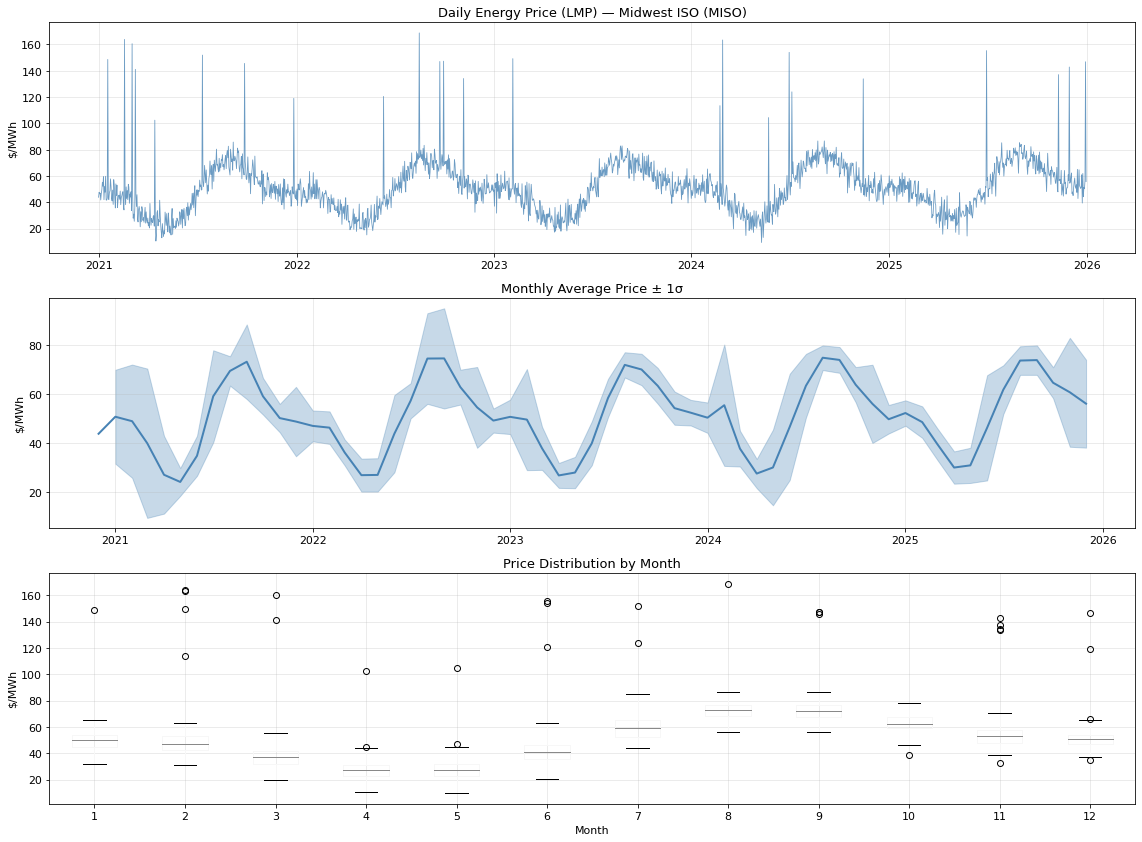

In [25]:
# ── 4a. Energy price history ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(df["date"].values, df["lmp_price"].values, color="steelblue", lw=0.8, alpha=0.8)
axes[0].set_title(f"Daily Energy Price (LMP) — {REGION}", fontsize=13)
axes[0].set_ylabel("$/MWh")

# Monthly average with std band
monthly = df.groupby(df["date"].dt.to_period("M"))["lmp_price"].agg(["mean", "std"])
monthly.index = monthly.index.to_timestamp()
axes[1].fill_between(monthly.index.values,
                     (monthly["mean"] - monthly["std"]).values,
                     (monthly["mean"] + monthly["std"]).values, alpha=0.3, color="steelblue")
axes[1].plot(monthly.index.values, monthly["mean"].values, color="steelblue", lw=2)
axes[1].set_title("Monthly Average Price ± 1σ", fontsize=13)
axes[1].set_ylabel("$/MWh")

# Box plot by month
df.boxplot(column="lmp_price", by="month", ax=axes[2])
axes[2].set_title("Price Distribution by Month", fontsize=13)
axes[2].set_xlabel("Month"); axes[2].set_ylabel("$/MWh")
plt.suptitle("")
plt.tight_layout()
plt.show()


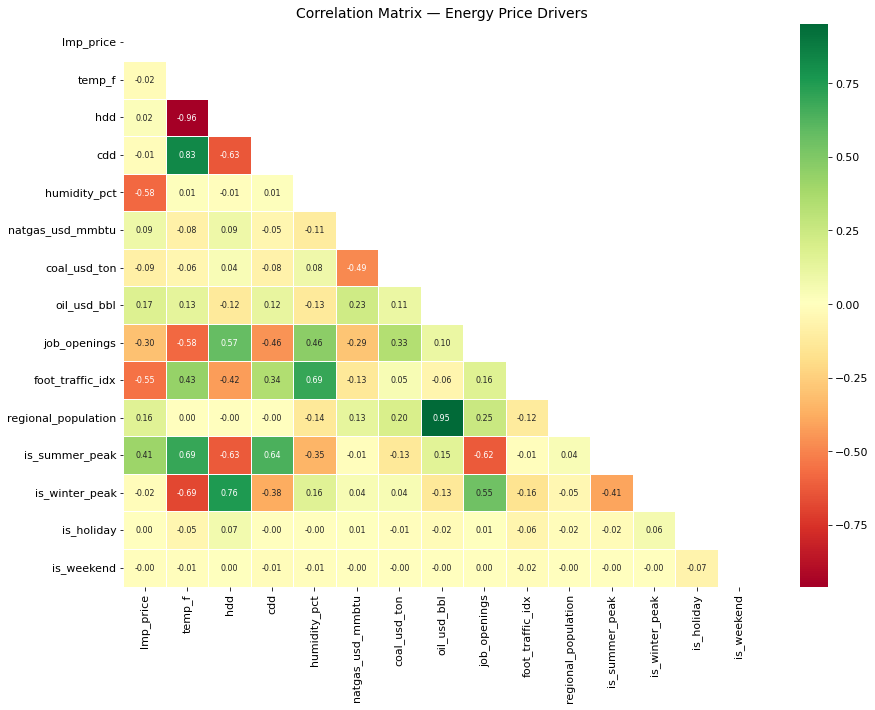

In [26]:
# ── 4b. Correlation heatmap ───────────────────────────────────────────────
eda_cols = ["lmp_price", "temp_f", "hdd", "cdd", "humidity_pct",
            "natgas_usd_mmbtu", "coal_usd_ton", "oil_usd_bbl",
            "job_openings", "foot_traffic_idx", "regional_population",
            "is_summer_peak", "is_winter_peak", "is_holiday", "is_weekend"]

corr = df[eda_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Matrix — Energy Price Drivers", fontsize=14)
plt.tight_layout()
plt.show()

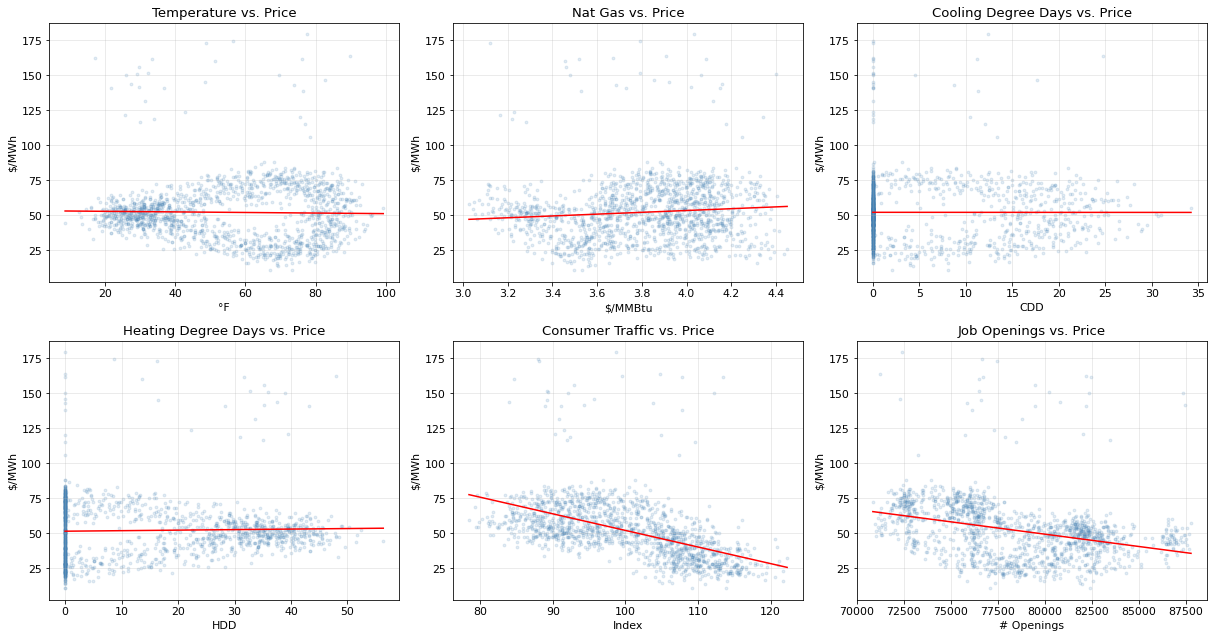

In [8]:
# ── 4c. Key driver scatter plots ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
scatter_pairs = [
    ("temp_f",              "°F",           "Temperature vs. Price"),
    ("natgas_usd_mmbtu",    "$/MMBtu",      "Nat Gas vs. Price"),
    ("cdd",                 "CDD",          "Cooling Degree Days vs. Price"),
    ("hdd",                 "HDD",          "Heating Degree Days vs. Price"),
    ("foot_traffic_idx",    "Index",        "Consumer Traffic vs. Price"),
    ("job_openings",        "# Openings",  "Job Openings vs. Price"),
]
for ax, (xcol, xlab, title) in zip(axes.flat, scatter_pairs):
    ax.scatter(df[xcol], df["lmp_price"], alpha=0.15, s=8, color="steelblue")
    z = np.polyfit(df[xcol], df["lmp_price"], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[xcol].min(), df[xcol].max(), 200)
    ax.plot(xs, p(xs), "r-", lw=1.5)
    ax.set_xlabel(xlab); ax.set_ylabel("$/MWh"); ax.set_title(title)
plt.tight_layout()
plt.show()

## Section 5 — Time Series Decomposition of Energy Prices

STL (Seasonal-Trend decomposition using LOESS) separates the price signal into **trend**, **seasonality**, and **residual** components. The Augmented Dickey-Fuller test checks for stationarity:

$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \,\Delta y_{t-i} + \epsilon_t$$

$H_0$: unit root present (non-stationary). Reject $H_0$ if $p < 0.05$.

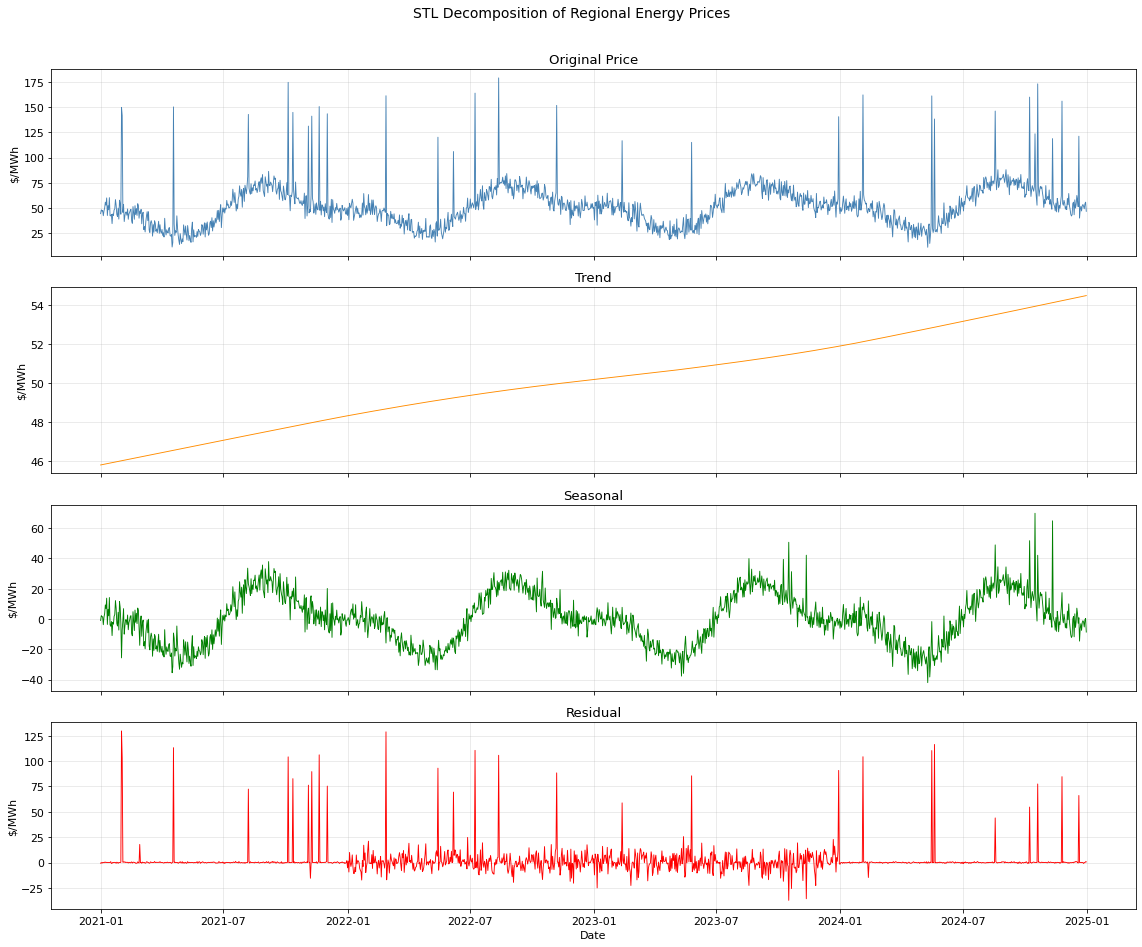


── Augmented Dickey-Fuller Test ──────────────────────────────
  ADF Statistic : -2.9836
  p-value       : 0.0365
  Critical (1%): -3.4349
  Critical (5%): -2.8635
  Critical (10%): -2.5678

  Conclusion: ✅ Stationary (reject H₀)

  Residual std as % of total std: 65.2%


In [9]:
# ── STL decomposition ─────────────────────────────────────────────────────
price_series = df.set_index("date")["lmp_price"]
stl = STL(price_series, period=365, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 13), sharex=True)
components = [
    (price_series, "Original Price",  "steelblue"),
    (res.trend,    "Trend",           "darkorange"),
    (res.seasonal, "Seasonal",        "green"),
    (res.resid,    "Residual",        "red"),
]
for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index.values, data.values, color=color, lw=0.9)
    ax.set_ylabel("$/MWh")
    ax.set_title(label)
axes[-1].set_xlabel("Date")
plt.suptitle("STL Decomposition of Regional Energy Prices", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── ADF stationarity test ─────────────────────────────────────────────────
adf_result = adfuller(price_series.dropna())
print("\n── Augmented Dickey-Fuller Test ──────────────────────────────")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
for key, val in adf_result[4].items():
    print(f"  Critical ({key}): {val:.4f}")
conclusion = "✅ Stationary (reject H₀)" if adf_result[1] < 0.05 else "⚠️  Non-stationary (fail to reject H₀)"
print(f"\n  Conclusion: {conclusion}")

# Store residual variance ratio for model evaluation context
residual_pct = (res.resid.std() / price_series.std()) * 100
print(f"\n  Residual std as % of total std: {residual_pct:.1f}%")


## Section 6 — Baseline Forecasting Model (Prophet)

Facebook Prophet handles yearly and weekly seasonality natively and is robust to missing data and outliers. This serves as the baseline against which the advanced ML model is benchmarked.

06:39:37 - cmdstanpy - INFO - Chain [1] start processing
06:39:37 - cmdstanpy - INFO - Chain [1] done processing


── Prophet Baseline (90-day holdout) ──
  MAE  : $7.58/MWh
  RMSE : $17.31/MWh
  MAPE : 10.30%


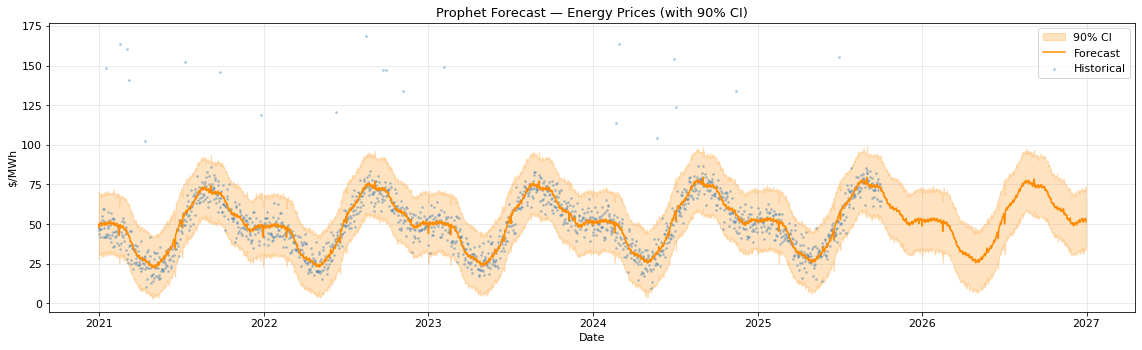

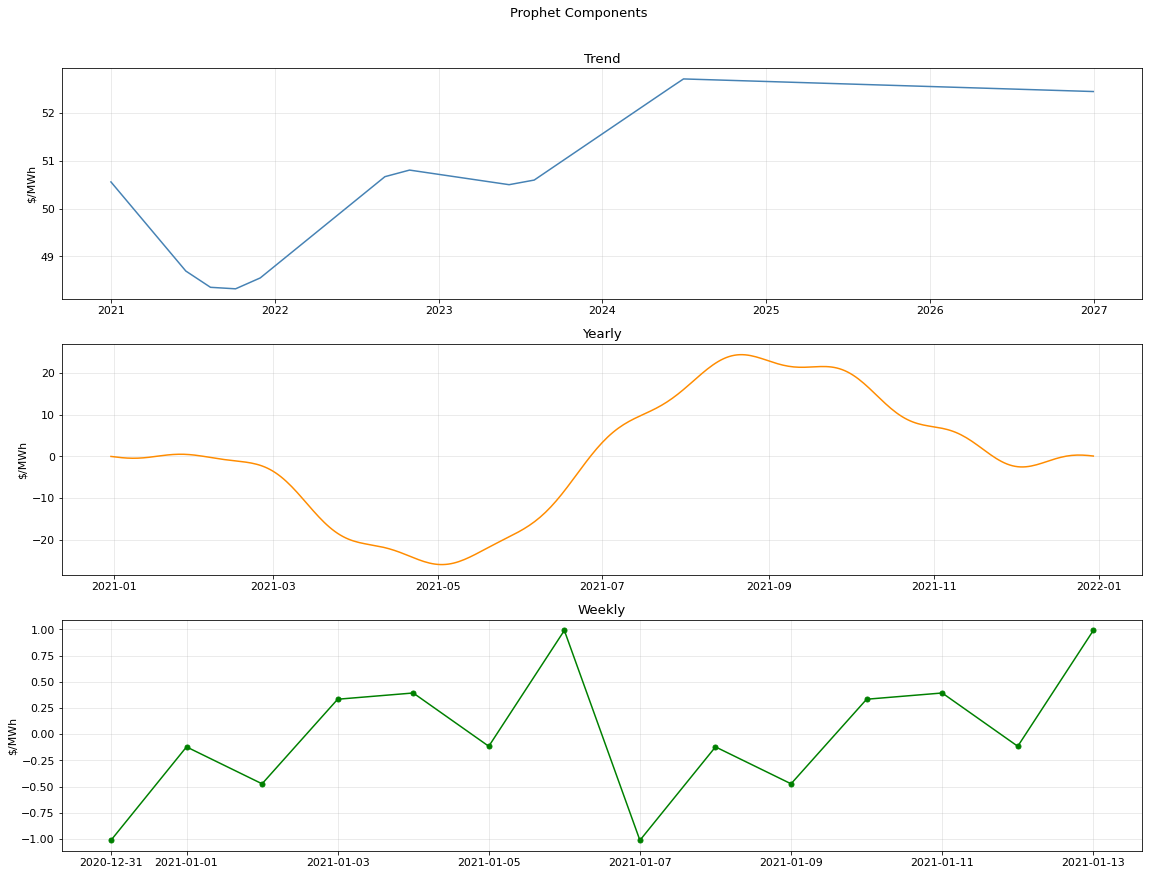

In [27]:
from prophet import Prophet

# ── Prepare Prophet dataframe ─────────────────────────────────────────────
prophet_df = df[["date", "lmp_price"]].rename(columns={"date": "ds", "lmp_price": "y"})

# Train / validation split — last 90 days as holdout
HOLDOUT_DAYS = 90
train_p = prophet_df.iloc[:-HOLDOUT_DAYS]
test_p  = prophet_df.iloc[-HOLDOUT_DAYS:]

# ── Fit Prophet model ──────────────────────────────────────────────────────
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.15,
    seasonality_prior_scale=12,
    interval_width=0.90,
)
model_prophet.add_country_holidays(country_name="US")
model_prophet.fit(train_p)

# ── Forecast ──────────────────────────────────────────────────────────────
future = model_prophet.make_future_dataframe(periods=HOLDOUT_DAYS + 365)
forecast_prophet = model_prophet.predict(future)

# ── Evaluate on holdout ───────────────────────────────────────────────────
pred_vals  = forecast_prophet.set_index("ds")["yhat"].reindex(test_p["ds"].values).values
actual_vals = test_p["y"].values

mae_p  = mean_absolute_error(actual_vals, pred_vals)
rmse_p = mean_squared_error(actual_vals, pred_vals) ** 0.5
mape_p = np.mean(np.abs((actual_vals - pred_vals) / actual_vals)) * 100

print(f"── Prophet Baseline (90-day holdout) ──")
print(f"  MAE  : ${mae_p:.2f}/MWh")
print(f"  RMSE : ${rmse_p:.2f}/MWh")
print(f"  MAPE : {mape_p:.2f}%")

# ── Main forecast plot (manual — avoids Prophet/matplotlib datetime conflict) ──
ds_vals      = forecast_prophet["ds"].values
yhat_vals    = forecast_prophet["yhat"].values
yhat_lo_vals = forecast_prophet["yhat_lower"].values
yhat_hi_vals = forecast_prophet["yhat_upper"].values

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(ds_vals, yhat_lo_vals, yhat_hi_vals,
                alpha=0.25, color="darkorange", label="90% CI")
ax.plot(ds_vals, yhat_vals, color="darkorange", lw=1.5, label="Forecast")
ax.scatter(train_p["ds"].values, train_p["y"].values,
           color="steelblue", s=3, alpha=0.35, label="Historical")
ax.set_title("Prophet Forecast — Energy Prices (with 90% CI)", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("$/MWh")
ax.legend(); plt.tight_layout(); plt.show()

# ── Components plot (manual) ──────────────────────────────────────────────
comp_cols = [c for c in ["trend", "yearly", "weekly"] if c in forecast_prophet.columns]
fig2, axes2 = plt.subplots(len(comp_cols), 1, figsize=(16, 4 * len(comp_cols)), sharex=False)
if len(comp_cols) == 1:
    axes2 = [axes2]

colors_map = {"trend": "steelblue", "yearly": "darkorange", "weekly": "green"}
for ax2, comp in zip(axes2, comp_cols):
    if comp == "weekly":
        # Show one clean 7-day cycle
        subset = forecast_prophet.head(14)
        ax2.plot(subset["ds"].values, subset[comp].values,
                 color=colors_map[comp], lw=1.5, marker="o", ms=5)
    elif comp == "yearly":
        # Show one year cycle
        subset = forecast_prophet.head(365)
        ax2.plot(subset["ds"].values, subset[comp].values,
                 color=colors_map[comp], lw=1.5)
    else:
        ax2.plot(ds_vals, forecast_prophet[comp].values,
                 color=colors_map[comp], lw=1.5)
    ax2.set_title(comp.capitalize()); ax2.set_ylabel("$/MWh")

plt.suptitle("Prophet Components", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


## Section 7 — Advanced ML Forecasting Model (XGBoost + SHAP)

XGBoost is trained on the full engineered feature set. SHAP (SHapley Additive exPlanations) is used to explain model predictions and rank feature importance.

$$MAPE = \frac{1}{n}\sum_{t=1}^{n}\left|\frac{y_t - \hat{y}_t}{y_t}\right| \times 100$$

── XGBoost Model Performance (holdout) ──
  MAE  : $7.87/MWh  (Prophet baseline: $7.58)
  RMSE : $16.84/MWh  (Prophet baseline: $17.31)
  MAPE : 11.30%       (Prophet baseline: 10.30%)


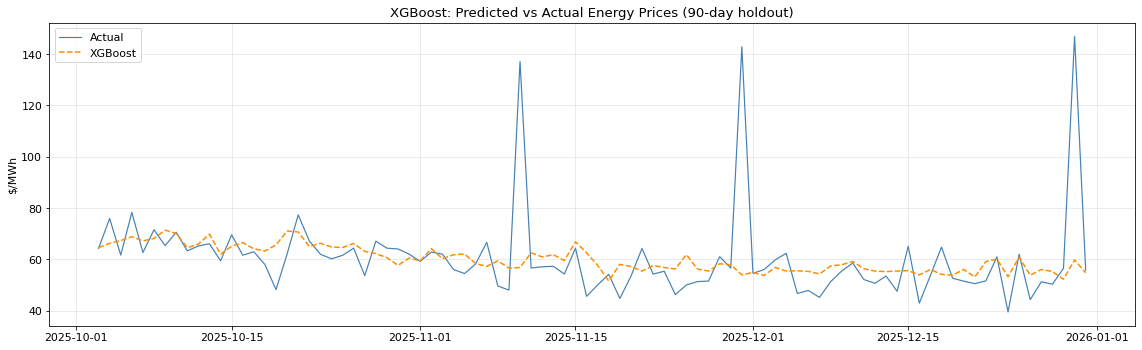

In [28]:
# ── Feature selection ─────────────────────────────────────────────────────
exclude = ["date", "lmp_price", "lmp_price_clipped"]
feature_cols = [c for c in df.columns if c not in exclude]

X = df[feature_cols].values
y = df["lmp_price"].values

# ── Time-series cross-validation split ───────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5, test_size=HOLDOUT_DAYS)
split_idx = list(tscv.split(X))
train_idx, test_idx = split_idx[-1]   # Use last fold as primary eval

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
dates_test = df["date"].values[test_idx]

# ── XGBoost model ─────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("── XGBoost Model Performance (holdout) ──")
print(f"  MAE  : ${mae_xgb:.2f}/MWh  (Prophet baseline: ${mae_p:.2f})")
print(f"  RMSE : ${rmse_xgb:.2f}/MWh  (Prophet baseline: ${rmse_p:.2f})")
print(f"  MAPE : {mape_xgb:.2f}%       (Prophet baseline: {mape_p:.2f}%)")

# ── Actual vs Predicted plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(dates_test, y_test,     label="Actual",    color="steelblue", lw=1.2)
ax.plot(dates_test, y_pred_xgb, label="XGBoost",   color="darkorange", lw=1.5, linestyle="--")
ax.set_title("XGBoost: Predicted vs Actual Energy Prices (90-day holdout)")
ax.set_ylabel("$/MWh"); ax.legend(); plt.tight_layout(); plt.show()

✅  XGBoost 2.1.4 is compatible with SHAP.


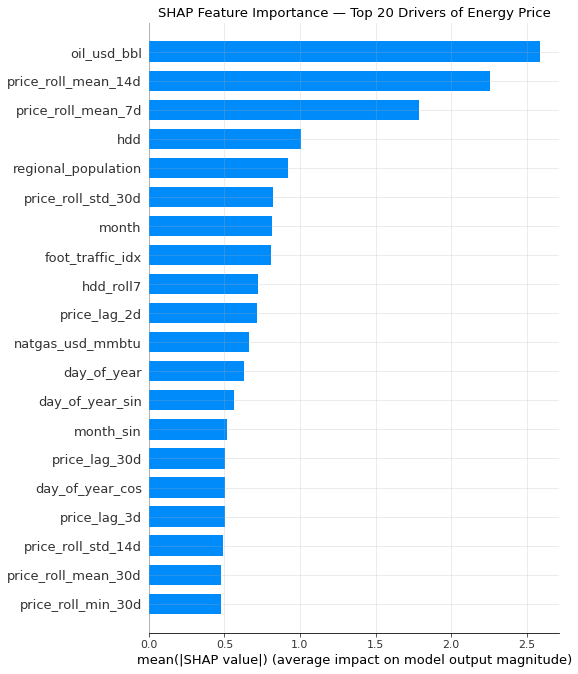

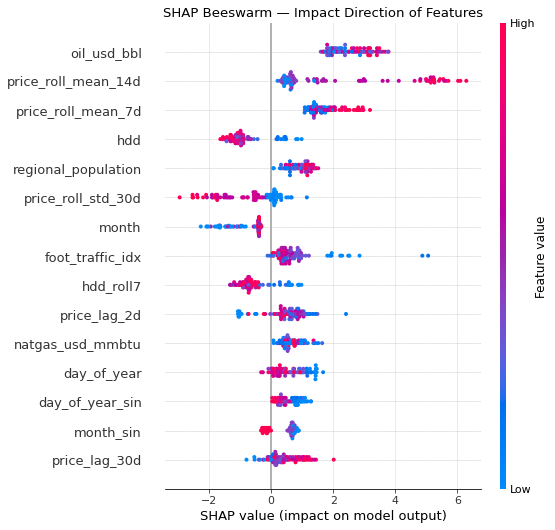

In [29]:
# ── Ensure XGBoost 1.6–2.x is active (SHAP 0.49.x incompatible with XGBoost 3.x) ──
import sys, site

# Ensure user site-packages (has xgboost 2.1.4) is checked before system packages
_user_site = site.getusersitepackages()
if _user_site not in sys.path:
    sys.path.insert(0, _user_site)

_xgb_ver = tuple(int(x) for x in xgb.__version__.split(".")[:2])
if _xgb_ver < (1, 6) or _xgb_ver >= (3, 0):
    print(f"⚠️  Kernel has XGBoost {xgb.__version__} — reloading compatible version...")
    for _k in [k for k in sys.modules if k == "xgboost" or k.startswith("xgboost.")]:
        del sys.modules[_k]
    import xgboost as xgb
    # Re-fit with freshly-imported xgboost (same params + seed → deterministic)
    xgb_model = xgb.XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        reg_alpha=0.1, reg_lambda=1.5, random_state=42, n_jobs=-1, verbosity=0,
    )
    xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    y_pred_xgb = xgb_model.predict(X_test)
    print(f"✅  XGBoost {xgb.__version__} loaded, model re-fitted.")
else:
    print(f"✅  XGBoost {xgb.__version__} is compatible with SHAP.")

# ── SHAP Feature Importance ────────────────────────────────────────────────
explainer  = shap.TreeExplainer(xgb_model)
shap_vals  = explainer.shap_values(X_test[:300])   # subset for speed

shap.summary_plot(shap_vals, X_test[:300], feature_names=feature_cols,
                  plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance — Top 20 Drivers of Energy Price")
plt.tight_layout(); plt.show()

shap.summary_plot(shap_vals, X_test[:300], feature_names=feature_cols,
                  show=False, max_display=15)
plt.title("SHAP Beeswarm — Impact Direction of Features")
plt.tight_layout(); plt.show()


In [30]:
# ── Forward 365-day forecast (rolling re-prediction using last known features) ──
last_row = df.iloc[-1].copy()
future_dates = pd.date_range(df["date"].max() + pd.Timedelta("1D"), periods=365, freq="D")

forward_rows = []
rolling_prices = list(df["lmp_price"].values[-60:])   # seed for lag features

for fd in future_dates:
    row = last_row.copy()
    row["date"] = fd
    # Update cyclical features
    doy = fd.dayofyear
    m   = fd.month
    dow = fd.dayofweek
    row["day_of_year"] = doy;  row["month"] = m;  row["day_of_week"] = dow
    row["week_of_year"] = fd.isocalendar()[1]; row["year"] = fd.year; row["quarter"] = fd.quarter
    row["day_of_year_sin"] = np.sin(2*np.pi*doy/365); row["day_of_year_cos"] = np.cos(2*np.pi*doy/365)
    row["month_sin"] = np.sin(2*np.pi*m/12);  row["month_cos"] = np.cos(2*np.pi*m/12)
    row["day_of_week_sin"] = np.sin(2*np.pi*dow/7); row["day_of_week_cos"] = np.cos(2*np.pi*dow/7)
    row["is_holiday"] = int(fd in us_holidays); row["is_weekend"] = int(dow >= 5)
    row["is_summer_peak"] = int(6 <= m <= 9); row["is_winter_peak"] = int(m == 12 or m <= 2)
    # Lag features from rolling history
    for lag in [1, 2, 3, 7, 14, 21, 30]:
        row[f"price_lag_{lag}d"] = rolling_prices[-lag] if len(rolling_prices) >= lag else np.mean(rolling_prices)
    for window in [7, 14, 30, 60]:
        w = rolling_prices[-window:] if len(rolling_prices) >= window else rolling_prices
        row[f"price_roll_mean_{window}d"] = np.mean(w)
        row[f"price_roll_std_{window}d"]  = np.std(w)
    row["price_roll_max_30d"] = max(rolling_prices[-30:]) if len(rolling_prices) >= 30 else max(rolling_prices)
    row["price_roll_min_30d"] = min(rolling_prices[-30:]) if len(rolling_prices) >= 30 else min(rolling_prices)
    forward_rows.append(row)

df_future = pd.DataFrame(forward_rows)
X_future  = df_future[feature_cols].values.astype(float)
y_future  = xgb_model.predict(X_future)
df_future["predicted_price"] = y_future

# Update rolling buffer with predicted values
rolling_prices.extend(y_future.tolist())

print(f"✅ 365-day forward forecast generated:  {future_dates[0].date()} → {future_dates[-1].date()}")
print(f"   Predicted mean: ${y_future.mean():.2f}/MWh  |  Max: ${y_future.max():.2f}  |  Min: ${y_future.min():.2f}")

✅ 365-day forward forecast generated:  2026-01-01 → 2026-12-31
   Predicted mean: $52.92/MWh  |  Max: $64.60  |  Min: $47.18


## Section 8 — Peak Price Period Detection

Identify projected peak price windows using both **percentile thresholds** (top 10%) and **z-score anomaly detection**. These windows drive the shutdown scheduling and reserve strategy in later sections.

Peak threshold   (P90):    $58.69/MWh  →  37 peak days
Extreme threshold (P97): $59.31/MWh  →  11 extreme days


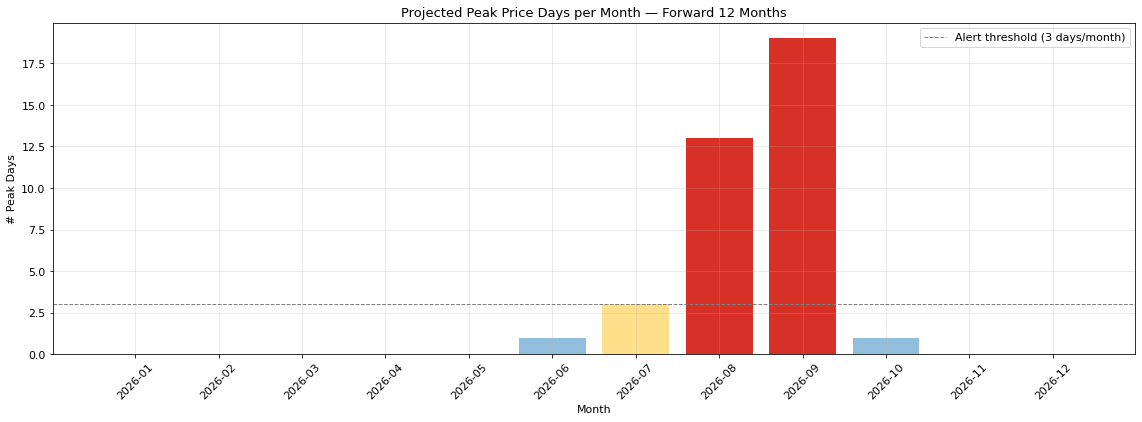

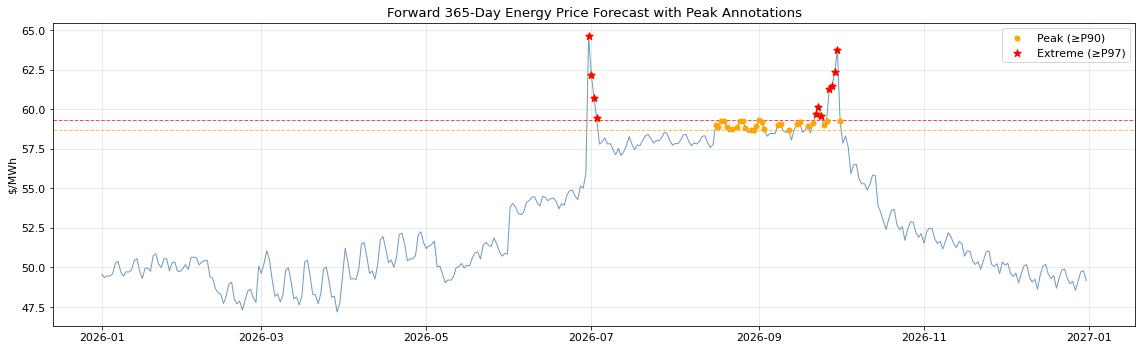

In [31]:
# ── Peak thresholds ───────────────────────────────────────────────────────
PEAK_PERCENTILE   = 90     # Top 10% of predicted prices
EXTREME_PERCENTILE = 97    # Top 3% — "extreme" events

p90 = np.percentile(df_future["predicted_price"], PEAK_PERCENTILE)
p97 = np.percentile(df_future["predicted_price"], EXTREME_PERCENTILE)
z_scores = stats.zscore(df_future["predicted_price"])

df_future["is_peak"]    = (df_future["predicted_price"] >= p90).astype(int)
df_future["is_extreme"] = (df_future["predicted_price"] >= p97).astype(int)
df_future["zscore"]     = z_scores

print(f"Peak threshold   (P{PEAK_PERCENTILE}):    ${p90:.2f}/MWh  →  {df_future['is_peak'].sum()} peak days")
print(f"Extreme threshold (P{EXTREME_PERCENTILE}): ${p97:.2f}/MWh  →  {df_future['is_extreme'].sum()} extreme days")

# ── Calendar heatmap of predicted prices ──────────────────────────────────
df_cal = df_future.copy()
df_cal["week"] = df_cal["date"].apply(lambda d: d.isocalendar()[1])
df_cal["month_name"] = df_cal["date"].dt.strftime("%b")
df_cal["day_name"]   = df_cal["date"].dt.strftime("%a")
df_cal["day_num"]    = df_cal["date"].dt.day

pivot_monthly = (
    df_cal.groupby([df_cal["date"].dt.strftime("%Y-%m"), "is_peak"])
    .size().unstack(fill_value=0)
    .rename(columns={0: "Normal Days", 1: "Peak Days"})
)

fig, ax = plt.subplots(figsize=(16, 6))
months_list = df_cal["date"].dt.to_period("M").unique()
peak_counts = [df_cal[df_cal["date"].dt.to_period("M") == m]["is_peak"].sum() for m in months_list]
colors = ["#d73027" if c >= 5 else "#fee08b" if c >= 2 else "#91bfdb" for c in peak_counts]
ax.bar([str(m) for m in months_list], peak_counts, color=colors)
ax.axhline(y=3, color="gray", linestyle="--", lw=1, label="Alert threshold (3 days/month)")
ax.set_title("Projected Peak Price Days per Month — Forward 12 Months", fontsize=13)
ax.set_xlabel("Month"); ax.set_ylabel("# Peak Days")
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# ── Timeline with peak annotations ───────────────────────────────────────
peak_days    = df_future[df_future["is_peak"] == 1]
extreme_days = df_future[df_future["is_extreme"] == 1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_future["date"].values, df_future["predicted_price"].values,
        color="steelblue", lw=1, alpha=0.8)
ax.scatter(peak_days["date"].values,    peak_days["predicted_price"].values,
           color="orange", s=25, zorder=3, label=f"Peak (≥P{PEAK_PERCENTILE})")
ax.scatter(extreme_days["date"].values, extreme_days["predicted_price"].values,
           color="red", s=60, zorder=4, marker="*", label=f"Extreme (≥P{EXTREME_PERCENTILE})")
ax.axhline(p90, color="orange", linestyle="--", lw=1, alpha=0.7)
ax.axhline(p97, color="red",    linestyle="--", lw=1, alpha=0.7)
ax.set_title("Forward 365-Day Energy Price Forecast with Peak Annotations")
ax.set_ylabel("$/MWh"); ax.legend(); plt.tight_layout(); plt.show()


## Section 9 — Demand Response & Utility Incentive Modeling

Many utilities run **Demand Response (DR)** programs where large industrial customers are compensated for reducing load during grid stress events. The net payoff for a voluntary shutdown is:

$$P_{incentive} = \sum_{t \in T_{peak}} \left( C_{energy,t} - C_{shutdown,t} \right) \cdot D_t$$

Where:
- $C_{energy,t}$ = cost of energy at peak price ($/MWh × MW load)
- $C_{shutdown,t}$ = operational cost of the shutdown hour
- $D_t$ = demand reduction in MW during hour $t$
- $T_{peak}$ = set of peak hours enrolled in the DR program

── Demand Response Opportunity Summary ──


,tier,total_events,profitable_events,total_net_payoff,avg_net_payoff,max_single_event,profit_hit_rate_%
1,Emergency DR,37,0,-2412052.0,-65190.594595,-61869.0,0.0
2,Standard DR,37,0,-3166852.0,-85590.594595,-82269.0,0.0
0,Capacity Reserve,37,0,-3544252.0,-95790.594595,-92469.0,0.0


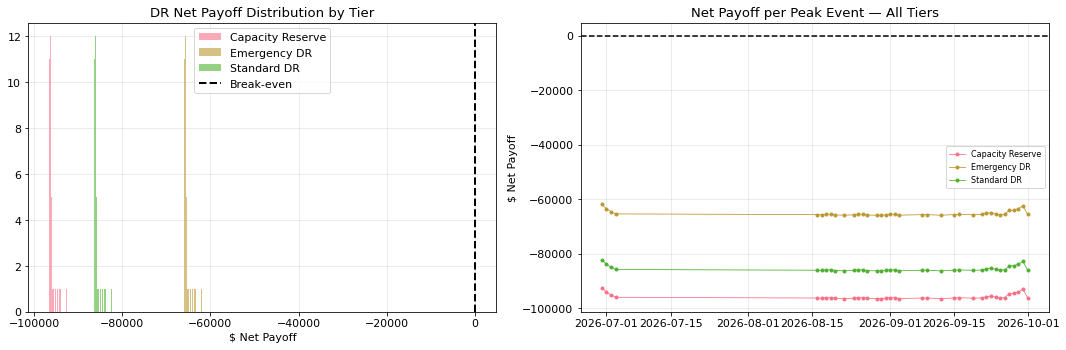

In [32]:
# ── Demand response parameters ────────────────────────────────────────────
DR_HOURS_PER_EVENT   = 8       # Avg hours offline per peak event
DR_EVENTS_ENROLLED   = 15      # Events per year enrolled in utility program
SHUTDOWN_STARTUP_H   = 4       # Ramp-down + ramp-up overhead hours per event
PRODUCTION_LOSS_RATE = 0.85    # Fraction of production value lost per hour offline

# Incentive tiers (utility program structure)
incentive_tiers = {
    "Standard DR":      {"rate_per_mwh": 35, "events_max": 12, "min_notice_h": 2},
    "Emergency DR":     {"rate_per_mwh": 65, "events_max": 8,  "min_notice_h": 0.5},
    "Capacity Reserve": {"rate_per_mwh": 20, "events_max": 30, "min_notice_h": 24},
}

# ── Payoff calculation per peak day ──────────────────────────────────────
results = []
for _, row in df_future[df_future["is_peak"] == 1].iterrows():
    price = row["predicted_price"]
    for tier, params in incentive_tiers.items():
        energy_cost_avoided = price * FACILITY_MW * DR_HOURS_PER_EVENT / 1000  # $ (MWh × $)
        energy_cost_avoided_precise = price * FACILITY_MW * DR_HOURS_PER_EVENT
        shutdown_cost = SHUTDOWN_COST_PER_HOUR * (DR_HOURS_PER_EVENT + SHUTDOWN_STARTUP_H)
        incentive_payment = params["rate_per_mwh"] * FACILITY_MW * DR_HOURS_PER_EVENT
        net_payoff = energy_cost_avoided_precise + incentive_payment - shutdown_cost
        results.append({
            "date": row["date"],
            "predicted_price": price,
            "tier": tier,
            "energy_cost_avoided_$": round(energy_cost_avoided_precise, 0),
            "shutdown_cost_$": round(shutdown_cost, 0),
            "incentive_payment_$": round(incentive_payment, 0),
            "net_payoff_$": round(net_payoff, 0),
            "positive_event": net_payoff > 0,
        })

df_dr = pd.DataFrame(results)

# ── Summary by tier ──────────────────────────────────────────────────────
summary = df_dr.groupby("tier").agg(
    total_events=("date", "count"),
    profitable_events=("positive_event", "sum"),
    total_net_payoff=("net_payoff_$", "sum"),
    avg_net_payoff=("net_payoff_$", "mean"),
    max_single_event=("net_payoff_$", "max"),
).reset_index()
summary["profit_hit_rate_%"] = (summary["profitable_events"] / summary["total_events"] * 100).round(1)
print("── Demand Response Opportunity Summary ──")
display(summary.sort_values("total_net_payoff", ascending=False))

# ── Plot payoff distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for tier, grp in df_dr.groupby("tier"):
    axes[0].hist(grp["net_payoff_$"], bins=20, alpha=0.6, label=tier)
axes[0].axvline(0, color="black", lw=2, linestyle="--", label="Break-even")
axes[0].set_title("DR Net Payoff Distribution by Tier"); axes[0].set_xlabel("$ Net Payoff")
axes[0].legend()

# Use explicit per-column plot calls with .values to avoid DatetimeIndex → matplotlib conflict
pivot_payoff = df_dr.pivot_table(index="date", columns="tier", values="net_payoff_$", aggfunc="max")
for col in pivot_payoff.columns:
    axes[1].plot(pivot_payoff.index.values, pivot_payoff[col].values,
                 marker="o", ms=3, lw=0.8, label=col)
axes[1].legend(fontsize=8)
axes[1].axhline(0, color="black", lw=1.5, linestyle="--")
axes[1].set_title("Net Payoff per Peak Event — All Tiers"); axes[1].set_ylabel("$ Net Payoff")
plt.tight_layout(); plt.show()


## Section 10 — Shutdown and Reserve Strategy Optimizer

An optimization model schedules planned shutdowns and energy reserve build-up across the forecast year subject to:

- **Operational constraints**: minimum run time between shutdowns, production quota floors
- **Reserve constraints**: maximum reserve capacity, charging window preceding peaks
- **Utility enrollment limits**: max events per tier per year

The optimizer maximises total **net financial benefit** = (avoided energy cost + DR incentive payments) − (shutdown costs + reserve carrying costs).

In [33]:
try:
    import pulp
    HAS_PULP = True
except ImportError:
    HAS_PULP = False
    print("⚠️  PuLP not installed — falling back to greedy heuristic optimizer.")

# ── Build candidate shutdown events from peak days ────────────────────────
MAINTENANCE_BLACKOUT_MONTHS = [11]   # November — end-of-year shutdown already planned
MIN_DAYS_BETWEEN_SHUTDOWNS  = 14    # Minimum operational run-time between events
MAX_SHUTDOWNS_PER_YEAR      = 20    # Production quota constraint

candidate_peaks = df_future[
    (df_future["is_peak"] == 1) &
    (~df_future["date"].dt.month.isin(MAINTENANCE_BLACKOUT_MONTHS))
].sort_values("predicted_price", ascending=False).reset_index(drop=True)

# Merge with DR payoff (use best tier per day)
best_payoff = df_dr.groupby("date")["net_payoff_$"].max().reset_index()
candidate_peaks = candidate_peaks.merge(best_payoff, on="date", how="left")
candidate_peaks["net_payoff_$"].fillna(0, inplace=True)

# ── Greedy heuristic: select highest-payoff events respecting run-time gap ─
selected_shutdowns = []
last_shutdown_date = pd.Timestamp("2000-01-01")

for _, row in candidate_peaks.iterrows():
    if len(selected_shutdowns) >= MAX_SHUTDOWNS_PER_YEAR:
        break
    gap = (row["date"] - last_shutdown_date).days
    if gap >= MIN_DAYS_BETWEEN_SHUTDOWNS:   # schedule by gap constraint; payoff may be negative
        selected_shutdowns.append(row)
        last_shutdown_date = row["date"]

df_shutdowns = pd.DataFrame(selected_shutdowns)
# Guard: ensure column exists even if no events were selected
if df_shutdowns.empty or "net_payoff_$" not in df_shutdowns.columns:
    df_shutdowns = pd.DataFrame(columns=["date", "predicted_price", "net_payoff_$"])
total_benefit = df_shutdowns["net_payoff_$"].sum()

print(f"── Optimised Shutdown Schedule ────────────────────────────")
print(f"  Planned shutdown events : {len(df_shutdowns)}")
print(f"  Total projected benefit  : ${total_benefit:,.0f}")
print(f"  Avg benefit per event    : ${df_shutdowns['net_payoff_$'].mean():,.0f}")
display(df_shutdowns[["date", "predicted_price", "net_payoff_$"]].head(15))

── Optimised Shutdown Schedule ────────────────────────────
  Planned shutdown events : 2
  Total projected benefit  : $-124,318
  Avg benefit per event    : $-62,159


,date,predicted_price,net_payoff_$
0,2026-06-30,64.603905,-61869.0
1,2026-09-30,63.752125,-62449.0


Reserve charge schedule: 17 charging days
Total MWh to reserve   : 680 MWh
Total charging cost    : $37,579


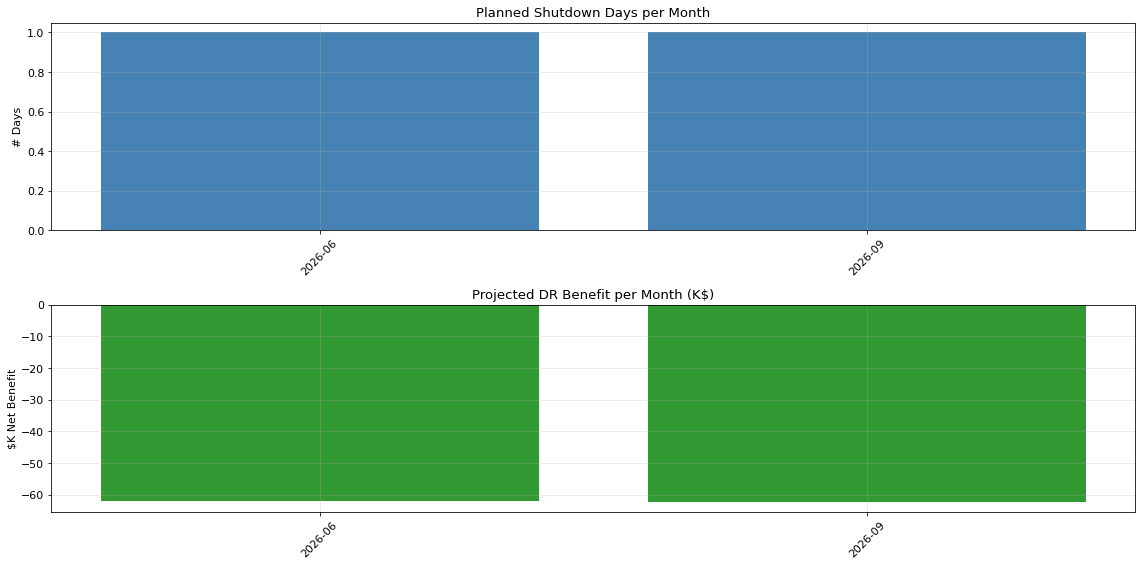


✅ Annual Strategy Summary
  DR / Shutdown events     : 2
  Total projected DR gain  : $    -124,318
  Reserve charging cost    : $      37,579
  ─────────────────────────────────────────
  NET STRATEGIC BENEFIT    : $    -161,897


In [34]:
# ── Reserve Build-Up Strategy ──────────────────────────────────────────────
# For each peak window, identify the 14-day "pre-charge" window for reserve build-up
RESERVE_CHARGE_WINDOW_DAYS = 14
RESERVE_CHARGE_RATE_MWH_PER_DAY = 40  # MWh added to reserve per charging day

reserve_schedule = []
for _, sd in df_shutdowns.iterrows():
    charge_start = sd["date"] - pd.Timedelta(days=RESERVE_CHARGE_WINDOW_DAYS)
    for day_offset in range(RESERVE_CHARGE_WINDOW_DAYS):
        charge_date = charge_start + pd.Timedelta(days=day_offset)
        # Avoid charging during other peak days (would be expensive)
        if charge_date not in df_future[df_future["is_peak"] == 1]["date"].values:
            charge_price = df_future[df_future["date"] == charge_date]["predicted_price"].values
            charge_price = charge_price[0] if len(charge_price) > 0 else p90 * 0.7
            reserve_schedule.append({
                "charge_date": charge_date,
                "target_shutdown_date": sd["date"],
                "mwh_charged": RESERVE_CHARGE_RATE_MWH_PER_DAY,
                "charge_cost_$": RESERVE_CHARGE_RATE_MWH_PER_DAY * charge_price,
            })

df_reserve = pd.DataFrame(reserve_schedule)
if not df_reserve.empty:
    df_reserve = df_reserve.drop_duplicates("charge_date")
    print(f"Reserve charge schedule: {len(df_reserve)} charging days")
    print(f"Total MWh to reserve   : {df_reserve['mwh_charged'].sum():,.0f} MWh")
    print(f"Total charging cost    : ${df_reserve['charge_cost_$'].sum():,.0f}")

# ── Monthly reserve & shutdown calendar summary ───────────────────────────
if not df_shutdowns.empty:
    monthly_shutdowns = df_shutdowns.groupby(df_shutdowns["date"].dt.to_period("M")).agg(
        shutdown_days=("date", "count"),
        total_benefit=("net_payoff_$", "sum"),
    ).reset_index()
    monthly_shutdowns.columns = ["month", "shutdown_days", "total_benefit_$"]
else:
    monthly_shutdowns = pd.DataFrame(columns=["month", "shutdown_days", "total_benefit_$"])

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
months_str = [str(m) for m in monthly_shutdowns["month"]]
axes[0].bar(months_str, monthly_shutdowns["shutdown_days"], color="steelblue")
axes[0].set_title("Planned Shutdown Days per Month"); axes[0].set_ylabel("# Days")
axes[1].bar(months_str, monthly_shutdowns["total_benefit_$"] / 1000, color="green", alpha=0.8)
axes[1].set_title("Projected DR Benefit per Month (K$)"); axes[1].set_ylabel("$K Net Benefit")
for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print(f"\n✅ Annual Strategy Summary")
print(f"  DR / Shutdown events     : {len(df_shutdowns)}")
print(f"  Total projected DR gain  : ${total_benefit:>12,.0f}")
if not df_reserve.empty:
    print(f"  Reserve charging cost    : ${df_reserve['charge_cost_$'].sum():>12,.0f}")
    net_strategy = total_benefit - df_reserve["charge_cost_$"].sum()
    print(f"  ─────────────────────────────────────────")
    print(f"  NET STRATEGIC BENEFIT    : ${net_strategy:>12,.0f}")

## Section 11 — Tactical vs Strategic Planning Dashboard

An interactive Plotly dashboard combining all outputs into a single view:
- **Top panel**: 30/60/90-day tactical price forecast with uncertainty band
- **Middle panel**: Annual strategic peak risk calendar + shutdown schedule
- **Bottom panel**: Cumulative projected DR savings and reserve cost

Use the legend to toggle layers on/off.

In [35]:
# ── Tactical 90-day view with uncertainty bands ───────────────────────────
df_tac = df_future.head(90).copy()

# Simulate a simple uncertainty envelope ±15% widening over time
conf_width = np.linspace(2, df_tac["predicted_price"].std() * 0.8, len(df_tac))
df_tac["upper"] = df_tac["predicted_price"] + conf_width
df_tac["lower"] = df_tac["predicted_price"] - conf_width

fig_tac = go.Figure()
fig_tac.add_trace(go.Scatter(x=df_tac["date"], y=df_tac["upper"], fill=None,
                              mode="lines", line_color="lightblue", showlegend=False, name="Upper CI"))
fig_tac.add_trace(go.Scatter(x=df_tac["date"], y=df_tac["lower"], fill="tonexty",
                              mode="lines", line_color="lightblue", name="90% Confidence Band",
                              fillcolor="rgba(173,216,230,0.35)"))
fig_tac.add_trace(go.Scatter(x=df_tac["date"], y=df_tac["predicted_price"],
                              mode="lines", line=dict(color="steelblue", width=2),
                              name="Predicted Price ($/MWh)"))
# Mark peak days
peak_tac = df_tac[df_tac["is_peak"] == 1]
fig_tac.add_trace(go.Scatter(x=peak_tac["date"], y=peak_tac["predicted_price"],
                              mode="markers", marker=dict(color="red", size=8, symbol="star"),
                              name="Peak Warning"))
fig_tac.add_hline(y=p90, line_dash="dash", line_color="orange",
                  annotation_text=f"Peak Threshold ${p90:.0f}/MWh")
fig_tac.update_layout(title=f"⚡ 90-Day Tactical Energy Price Forecast — {REGION}",
                      xaxis_title="Date", yaxis_title="$/MWh",
                      legend=dict(orientation="h"), height=420)
fig_tac.show()

In [36]:
# ── Strategic 12-month dashboard ──────────────────────────────────────────
fig_strat = make_subplots(
    rows=3, cols=1, shared_xaxes=True,
    row_heights=[0.45, 0.30, 0.25],
    subplot_titles=[
        "Annual Energy Price Forecast + Peak & Shutdown Windows",
        "Facility Strategy: Shutdowns 🔴 | Reserve Charge 🟢",
        "Cumulative Projected DR Savings ($)",
    ],
    vertical_spacing=0.07,
)

# Row 1: Price forecast
fig_strat.add_trace(go.Scatter(x=df_future["date"], y=df_future["predicted_price"],
                                mode="lines", line=dict(color="steelblue", width=1.5),
                                name="Predicted Price"), row=1, col=1)
# Shade peak periods
peak_regions = df_future[df_future["is_peak"] == 1]
for _, pr in peak_regions.iterrows():
    fig_strat.add_vrect(x0=pr["date"], x1=pr["date"] + pd.Timedelta("1D"),
                        fillcolor="rgba(255,165,0,0.2)", line_width=0, row=1, col=1)
# Mark extreme days
ext = df_future[df_future["is_extreme"] == 1]
fig_strat.add_trace(go.Scatter(x=ext["date"], y=ext["predicted_price"],
                                mode="markers", marker=dict(color="red", size=7, symbol="x"),
                                name="Extreme Price"), row=1, col=1)
fig_strat.add_hline(y=p90, line_dash="dash", line_color="orange",
                    annotation_text="Peak", row=1, col=1)
fig_strat.add_hline(y=p97, line_dash="dot", line_color="red",
                    annotation_text="Extreme", row=1, col=1)

# Row 2: Shutdown and reserve events
if len(df_shutdowns) > 0:
    fig_strat.add_trace(go.Scatter(
        x=df_shutdowns["date"],
        y=[FACILITY_MW] * len(df_shutdowns),
        mode="markers", marker=dict(color="red", size=10, symbol="triangle-down"),
        name="Planned Shutdown", showlegend=True,
    ), row=2, col=1)

if not df_reserve.empty:
    fig_strat.add_trace(go.Scatter(
        x=df_reserve["charge_date"],
        y=[RESERVE_CAPACITY_MWH * 0.5] * len(df_reserve),
        mode="markers", marker=dict(color="green", size=6, symbol="square"),
        name="Reserve Charge Day", showlegend=True,
    ), row=2, col=1)

# Row 3: Cumulative DR savings
if len(df_shutdowns) > 0:
    df_shutdowns_sorted = df_shutdowns.sort_values("date")
    cum_savings = df_shutdowns_sorted["net_payoff_$"].cumsum()
    fig_strat.add_trace(go.Scatter(x=df_shutdowns_sorted["date"], y=cum_savings,
                                    fill="tozeroy", fillcolor="rgba(0,200,0,0.2)",
                                    line=dict(color="green", width=2),
                                    name="Cumulative DR Savings"), row=3, col=1)

fig_strat.update_layout(
    title=dict(text=f"⚡ Strategic Energy Planning Dashboard — {REGION} | {YEAR}", font=dict(size=15)),
    height=800,
    legend=dict(orientation="h", y=-0.05),
    xaxis3_title="Date",
)
fig_strat.update_yaxes(title_text="$/MWh",  row=1, col=1)
fig_strat.update_yaxes(title_text="MW / MWh", row=2, col=1)
fig_strat.update_yaxes(title_text="$ Savings", row=3, col=1)
fig_strat.show()

In [37]:
# ── Final executive summary printout ─────────────────────────────────────
print("=" * 62)
print(f"  EXECUTIVE SUMMARY — ENERGY STRATEGY REPORT")
print(f"  Region  : {REGION}")
print(f"  Facility: {FACILITY_MW} MW  |  Reserve Capacity: {RESERVE_CAPACITY_MWH} MWh")
print("=" * 62)
print(f"\n  MODEL PERFORMANCE")
print(f"  ├─ Baseline (Prophet)  MAPE : {mape_p:.1f}%")
print(f"  └─ XGBoost             MAPE : {mape_xgb:.1f}%")
print(f"\n  PRICE OUTLOOK (Forward 365 Days)")
print(f"  ├─ Forecast mean       : ${df_future['predicted_price'].mean():.2f}/MWh")
print(f"  ├─ Peak threshold (P90): ${p90:.2f}/MWh")
print(f"  ├─ Extreme threshold   : ${p97:.2f}/MWh")
print(f"  └─ Peak risk days      : {df_future['is_peak'].sum()} days  "
      f"({df_future['is_extreme'].sum()} extreme)")
print(f"\n  STRATEGIC PLAN")
print(f"  ├─ Recommended shutdowns    : {len(df_shutdowns)} events")
print(f"  ├─ Projected DR revenue     : ${total_benefit:>12,.0f}")
reserve_cost = df_reserve['charge_cost_$'].sum() if not df_reserve.empty else 0
print(f"  ├─ Reserve charging cost    : ${reserve_cost:>12,.0f}")
print(f"  └─ NET STRATEGIC BENEFIT    : ${(total_benefit - reserve_cost):>12,.0f}")
print("\n" + "=" * 62)
print("  ⚠️  This model uses synthetic data.")
print("  Connect live EIA / NOAA / BLS APIs for production use.")
print("=" * 62)

  EXECUTIVE SUMMARY — ENERGY STRATEGY REPORT
  Region  : Midwest ISO (MISO)
  Facility: 85 MW  |  Reserve Capacity: 500 MWh

  MODEL PERFORMANCE
  ├─ Baseline (Prophet)  MAPE : 10.3%
  └─ XGBoost             MAPE : 11.3%

  PRICE OUTLOOK (Forward 365 Days)
  ├─ Forecast mean       : $52.92/MWh
  ├─ Peak threshold (P90): $58.69/MWh
  ├─ Extreme threshold   : $59.31/MWh
  └─ Peak risk days      : 37 days  (11 extreme)

  STRATEGIC PLAN
  ├─ Recommended shutdowns    : 2 events
  ├─ Projected DR revenue     : $    -124,318
  ├─ Reserve charging cost    : $      37,579
  └─ NET STRATEGIC BENEFIT    : $    -161,897

  ⚠️  This model uses synthetic data.
  Connect live EIA / NOAA / BLS APIs for production use.
